In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.neighbors import NearestNeighbors

In [2]:
exposure = pd.read_csv("../data/raw/2025-10-30_exposure.csv")
responses = pd.read_csv("../data/raw/2026-01-27_responses.csv")
feedback = pd.read_csv("../data/raw/2025-10-30_feedback.csv")

users = pd.read_csv("../data/raw/2025-10-30_users.csv")
user_thetas = pd.read_csv("../data/raw/2025-11-14_user_thetas.csv")

item_params = pd.read_csv("../data/raw/2025-11-04_item_parameters_Rasch.csv")
item_statistics = pd.read_csv("../data/raw/2025-11-04_item_statistics.csv")

questions = pd.read_csv("../data/raw/2025-10-30_questions.csv")
texts = pd.read_csv("../data/raw/question_texts_texts.csv")


print("exposure:", exposure.shape)
print("texts:", texts.shape)
print("responses:", responses.shape)
print("feedback:", feedback.shape)
print("users:", users.shape)
print("user_thetas:", user_thetas.shape)
print("item_params:", item_params.shape)
print("item_statistics:", item_statistics.shape)
print("questions:", questions.shape)


exposure: (159, 5)
texts: (159, 4)
responses: (97382, 15)
feedback: (26945, 8)
users: (6573, 10)
user_thetas: (2356, 3)
item_params: (879, 9)
item_statistics: (879, 9)
questions: (1164, 7)


In [3]:
exposure.head()

,sanity_text_id,n,serialNumber,title,pct
0,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2702,NaN,Vil du hjelpe oss med forskningen v+Ñr?,0.137611
1,3c792d1d-4254-4cd6-9add-f54548fcb0b4,165,HT_128_PremierLeague,Premier League,0.008403
2,193d0c96-d9ff-4984-9964-4304123f20a2,160,HT_127_Eliteserien,Eliteserien i fotball,0.008149
3,ffffece4-14da-4ed0-819a-a7039a0101d1,147,HT_52_Minecraft,Minecraft,0.007487
4,c83708d2-4a21-43ad-bea4-a193faac8d14,147,HT_139_Haier,Haier,0.007487


In [4]:
responses.head()

,answer_id,student_answer,student_id,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer,student_answer_bool,correct,item_id,question_id,text_id
0,125,True,6643,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1
1,126,True,6643,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,839fa70d1a2d,ability,NaN,multiChoice,True,True,True,2,2,1
2,127,True,6632,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1
3,128,True,6632,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,839fa70d1a2d,ability,NaN,multiChoice,True,True,True,2,2,1
4,129,True,6633,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1


In [5]:
questions.head()

,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ba19153d3561,bd938febbf0b,ability,HT_105_+ÿrner,multiChoice,True
1,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ea9c7a756e38,6865903547ca,ability,HT_105_+ÿrner,multiChoice,True
2,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ad690b948e2a,64596db46cd7,ability,HT_105_+ÿrner,multiChoice,True
3,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,c3fbfdd179ac,NaN,preference,HT_105_+ÿrner,scaleFeedback,NaN
4,0202b907-4516-4beb-8e07-759e473b5ea2,6fa81bbdb643,957bfc69375d,ability,HT_43_Astronaut,multiChoice,True


In [6]:
questions.describe(include='all')

,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer
count,1164,1164,891,1164,1162,1164,891
unique,159,766,888,2,158,5,2
top,50ff716b-f451-4fa4-9193-19cfd654df4f,ee21417e5bd7,f83db5312cbd,ability,HT_142_Thunberg,multiChoice,True
freq,19,8,2,1006,19,367,673


In [7]:
exposure.describe(include='all')

,sanity_text_id,n,serialNumber,title,pct
count,159,159.000000,158,159,159.000000
unique,159,NaN,158,159,NaN
top,91b545bd-9dad-42d8-aa78-a650f31ed6e8,NaN,HT_128_PremierLeague,Vil du hjelpe oss med forskningen v+Ñr?,NaN
freq,1,NaN,1,1,NaN
mean,NaN,123.490566,NaN,NaN,0.006289
std,NaN,206.703079,NaN,NaN,0.010527
min,NaN,63.000000,NaN,NaN,0.003209
25%,NaN,94.000000,NaN,NaN,0.004787
50%,NaN,108.000000,NaN,NaN,0.005500
75%,NaN,119.000000,NaN,NaN,0.006061


In [8]:
texts.describe(include='all')


,sanity_text_id,serialNumber,title,body
count,159,158,159,159
unique,159,158,159,159
top,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,HT_105_+ÿrner,+ÿrner,## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne. Foto....
freq,1,1,1,1


In [9]:
responses.describe(include='all')


,answer_id,student_answer,student_id,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer,student_answer_bool,correct,item_id,question_id,text_id
count,97382.000000,78746,97382.000000,97382,97382,97382,97382,92325,97382,97372,97382,97372,97382.000000,97382.000000,97382.000000
unique,NaN,2,NaN,154,509,1817,1,153,3,2,2,2,NaN,NaN,NaN
top,NaN,True,NaN,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,467726062e54,ability,HT_15_Dukker,multiChoice,True,True,True,NaN,NaN,NaN
freq,NaN,64521,NaN,5057,2538,2484,97382,1631,46438,57931,64521,68113,NaN,NaN,NaN
mean,184784.976885,NaN,3450.857489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,699.806361,299.033179,78.547380
std,50119.540276,NaN,2029.911685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,501.768395,187.621608,48.308446
min,125.000000,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000
25%,162104.250000,NaN,1876.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,273.000000,145.000000,37.000000
50%,191713.500000,NaN,3370.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,652.000000,297.000000,81.000000
75%,221524.500000,NaN,5275.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1034.000000,462.000000,122.000000


In [10]:
users.describe(include='all')


,user_id,username,role_id,role,classroom_id,classroom,school_id,school,parental_consent,student_consent
count,6573.000000,6573,6573.0,6573,6573.000000,6573,6573.0,6573,6573,2599
unique,NaN,6573,NaN,1,NaN,138,NaN,1,2,2
top,NaN,SunnSjef,NaN,Student,NaN,Skole 4,NaN,Pilot 1,True,True
freq,NaN,1,NaN,6573,NaN,180,NaN,6573,6559,2422
mean,3378.857599,NaN,3.0,NaN,80.494903,NaN,5.0,NaN,NaN,NaN
std,1941.376868,NaN,0.0,NaN,46.377990,NaN,0.0,NaN,NaN,NaN
min,18.000000,NaN,3.0,NaN,8.000000,NaN,5.0,NaN,NaN,NaN
25%,1697.000000,NaN,3.0,NaN,39.000000,NaN,5.0,NaN,NaN,NaN
50%,3380.000000,NaN,3.0,NaN,80.000000,NaN,5.0,NaN,NaN,NaN
75%,5060.000000,NaN,3.0,NaN,121.000000,NaN,5.0,NaN,NaN,NaN


In [11]:
user_thetas.describe(include='all')


,user_id,Rasch,3PL
count,2356.000000,2356.000000,2356.000000
mean,3472.773769,-0.000053,-0.061752
std,2024.815906,0.705808,0.911355
min,19.000000,-2.975077,-4.558115
25%,1893.750000,-0.418357,-0.564901
50%,3410.500000,0.056280,-0.005359
75%,5267.000000,0.479570,0.552612
max,6743.000000,1.860956,2.368929


In [12]:
item_params.describe(include='all')


,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
count,879.00000,879.0,879.000000,879.0,879.0,879,879,879,879
unique,NaN,NaN,NaN,NaN,NaN,150,499,876,150
top,NaN,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,72c71aec34fc,HT_72_Danmark
freq,NaN,NaN,NaN,NaN,NaN,18,8,2,18
mean,440.00000,1.0,-1.895709,0.0,1.0,NaN,NaN,NaN,NaN
std,253.88974,0.0,1.166142,0.0,0.0,NaN,NaN,NaN,NaN
min,1.00000,1.0,-5.183914,0.0,1.0,NaN,NaN,NaN,NaN
25%,220.50000,1.0,-2.714677,0.0,1.0,NaN,NaN,NaN,NaN
50%,440.00000,1.0,-1.892547,0.0,1.0,NaN,NaN,NaN,NaN
75%,659.50000,1.0,-1.130383,0.0,1.0,NaN,NaN,NaN,NaN


In [13]:
item_params_2 = item_params.copy()
item_params_2["item_id"] = item_params_2["item_id"].astype(str)

In [14]:
item_params_2.describe(include='all')

,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
count,879,879.0,879.000000,879.0,879.0,879,879,879,879
unique,879,NaN,NaN,NaN,NaN,150,499,876,150
top,225,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,72c71aec34fc,HT_72_Danmark
freq,1,NaN,NaN,NaN,NaN,18,8,2,18
mean,NaN,1.0,-1.895709,0.0,1.0,NaN,NaN,NaN,NaN
std,NaN,0.0,1.166142,0.0,0.0,NaN,NaN,NaN,NaN
min,NaN,1.0,-5.183914,0.0,1.0,NaN,NaN,NaN,NaN
25%,NaN,1.0,-2.714677,0.0,1.0,NaN,NaN,NaN,NaN
50%,NaN,1.0,-1.892547,0.0,1.0,NaN,NaN,NaN,NaN
75%,NaN,1.0,-1.130383,0.0,1.0,NaN,NaN,NaN,NaN


In [15]:
item_statistics.describe(include='all')


,item_id,n_responses,prop_correct,item_test_correlation,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber,avg_preference
count,879.000000,879.000000,879.000000,879.000000,879,879,879,879,879.000000
unique,NaN,NaN,NaN,NaN,153,498,876,153,NaN
top,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark,NaN
freq,NaN,NaN,NaN,NaN,18,8,2,18,NaN
mean,446.414107,83.315131,0.789122,0.287132,NaN,NaN,NaN,NaN,3.239964
std,256.412314,22.883077,0.158692,0.129781,NaN,NaN,NaN,NaN,0.374201
min,1.000000,13.000000,0.105263,-0.378340,NaN,NaN,NaN,NaN,2.369863
25%,225.500000,69.500000,0.706782,0.207907,NaN,NaN,NaN,NaN,2.966292
50%,447.000000,85.000000,0.827586,0.294629,NaN,NaN,NaN,NaN,3.205607
75%,668.500000,99.000000,0.912023,0.374056,NaN,NaN,NaN,NaN,3.530612


In [16]:
item_statistics_2 = item_statistics.copy()
item_statistics_2["item_id"] = item_params_2["item_id"].astype(str)

In [17]:
item_statistics_2.describe(include='all')

,item_id,n_responses,prop_correct,item_test_correlation,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber,avg_preference
count,879,879.000000,879.000000,879.000000,879,879,879,879,879.000000
unique,879,NaN,NaN,NaN,153,498,876,153,NaN
top,225,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark,NaN
freq,1,NaN,NaN,NaN,18,8,2,18,NaN
mean,NaN,83.315131,0.789122,0.287132,NaN,NaN,NaN,NaN,3.239964
std,NaN,22.883077,0.158692,0.129781,NaN,NaN,NaN,NaN,0.374201
min,NaN,13.000000,0.105263,-0.378340,NaN,NaN,NaN,NaN,2.369863
25%,NaN,69.500000,0.706782,0.207907,NaN,NaN,NaN,NaN,2.966292
50%,NaN,85.000000,0.827586,0.294629,NaN,NaN,NaN,NaN,3.205607
75%,NaN,99.000000,0.912023,0.374056,NaN,NaN,NaN,NaN,3.530612


In [18]:
feedback.describe(include='all')

,feedback_id,sanity_text_id,sanity_question_key,student_answer,student_id,scale,serialNumber,type
count,26945.000000,26945,26945,26286.000000,26945.000000,16566,16566,16566
unique,NaN,159,156,NaN,NaN,1,158,1
top,NaN,56c0e9bf-a4f1-4f6f-8153-6836ca2c81d6,b2147cfaeb93,NaN,NaN,preference,HT_08_Mobbing,scaleFeedback
freq,NaN,3347,546,NaN,NaN,16566,241,16566
mean,14212.403229,NaN,NaN,3.129042,3808.315123,NaN,NaN,NaN
std,8371.822835,NaN,NaN,1.315428,1950.015636,NaN,NaN,NaN
min,38.000000,NaN,NaN,1.000000,19.000000,NaN,NaN,NaN
25%,6828.000000,NaN,NaN,2.000000,2251.000000,NaN,NaN,NaN
50%,14129.000000,NaN,NaN,3.000000,4607.000000,NaN,NaN,NaN
75%,21461.000000,NaN,NaN,4.000000,5109.000000,NaN,NaN,NaN


In [19]:
user_thetas.head()

,user_id,Rasch,3PL
0,6208,0.554910,0.988615
1,6203,0.807340,1.179093
2,4929,-0.065195,0.142492
3,3138,0.697116,1.010295
4,3122,-0.019453,-0.016740


In [20]:
item_params.head()

,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
0,225,1,-2.158127,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,235d73d0ff8a,HT_01_Promp
1,226,1,-2.853890,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,77078ea940e0,HT_01_Promp
2,227,1,-3.415364,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,c602fd06a4ad,HT_01_Promp
3,228,1,-2.516826,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,78c8875d5160,f9e2db73e448,HT_01_Promp
4,229,1,-2.236764,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,7cf198887588,468728af46ce,HT_01_Promp


In [21]:
item_params.describe()

,item_id,a,b,g,u
count,879.00000,879.0,879.000000,879.0,879.0
mean,440.00000,1.0,-1.895709,0.0,1.0
std,253.88974,0.0,1.166142,0.0,0.0
min,1.00000,1.0,-5.183914,0.0,1.0
25%,220.50000,1.0,-2.714677,0.0,1.0
50%,440.00000,1.0,-1.892547,0.0,1.0
75%,659.50000,1.0,-1.130383,0.0,1.0
max,879.00000,1.0,2.295808,0.0,1.0


In [22]:
text_difficulty = item_params.groupby("sanity_text_id")["b"].mean().reset_index()
text_difficulty.rename(columns={"b": "text_difficulty"}, inplace=True)

In [23]:
text_difficulty.head()

,sanity_text_id,text_difficulty
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,-2.455900
1,0202b907-4516-4beb-8e07-759e473b5ea2,-1.796683
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,-1.595484
3,035af603-c895-4f40-a3e8-4b05a07a09bd,-1.738840
4,05c18c0e-b6b5-40b8-9009-130b044693c6,-1.201098


In [24]:
text_difficulty.describe(include='all')

,sanity_text_id,text_difficulty
count,150,150.000000
unique,150,NaN
top,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,NaN
freq,1,NaN
mean,NaN,-1.920610
std,NaN,0.677233
min,NaN,-3.608110
25%,NaN,-2.360198
50%,NaN,-1.877934
75%,NaN,-1.496732


In [25]:
text_difficulty = text_difficulty.merge(
    exposure[["sanity_text_id", "title", "serialNumber"]],
    on="sanity_text_id",
    how="left"
)

In [26]:
text_difficulty.head()

,sanity_text_id,text_difficulty,title,serialNumber
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,-2.455900,+ÿrner,HT_105_+ÿrner
1,0202b907-4516-4beb-8e07-759e473b5ea2,-1.796683,Astronaut,HT_43_Astronaut
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,-1.595484,Snork,HT_04_Snork
3,035af603-c895-4f40-a3e8-4b05a07a09bd,-1.738840,Miniatyrer - gjennom n+Ñl++yet,HT_125_Miniatyrer-William
4,05c18c0e-b6b5-40b8-9009-130b044693c6,-1.201098,NRK,HT_135_NRK


In [27]:
text_difficulty.describe(include='all')

,sanity_text_id,text_difficulty,title,serialNumber
count,150,150.000000,150,150
unique,150,NaN,150,150
top,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,NaN,+ÿrner,HT_105_+ÿrner
freq,1,NaN,1,1
mean,NaN,-1.920610,NaN,NaN
std,NaN,0.677233,NaN,NaN
min,NaN,-3.608110,NaN,NaN
25%,NaN,-2.360198,NaN,NaN
50%,NaN,-1.877934,NaN,NaN
75%,NaN,-1.496732,NaN,NaN


In [28]:
user_theta = user_thetas[["user_id", "Rasch"]].rename(columns={"Rasch": "theta"})

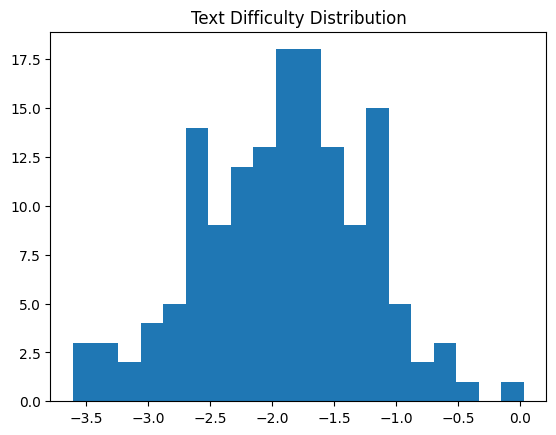

In [29]:
import matplotlib.pyplot as plt

plt.hist(text_difficulty["text_difficulty"], bins=20)
plt.title("Text Difficulty Distribution")
plt.show()

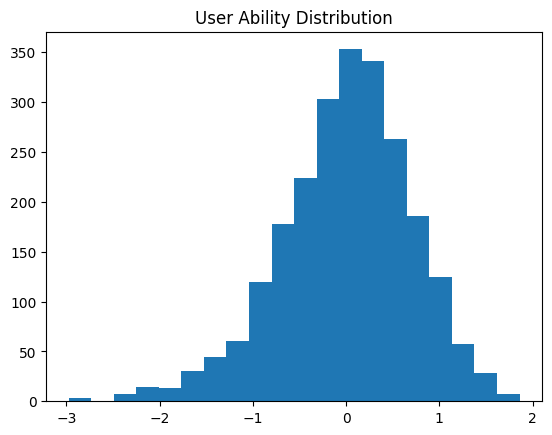

In [30]:
plt.hist(user_theta["theta"], bins=20)
plt.title("User Ability Distribution")
plt.show()

In [31]:
user_seen = responses.groupby("student_id")["sanity_text_id"].unique()

In [32]:
def recommend_texts(user_id, k=5):

    theta = user_theta.loc[user_theta.user_id == user_id, "theta"].values[0]

    seen = user_seen.get(user_id, [])

    candidates = text_difficulty[~text_difficulty["sanity_text_id"].isin(seen)].copy()

    candidates["distance"] = abs(candidates["text_difficulty"] - theta)

    return candidates.sort_values("distance").head(k)

In [33]:
recommend_texts(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber,distance
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen g+Ñr,HT_83_BoksenG+Ñr,0.526856
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det v+ªre litt ++remidd?,HT_117_Forskeporske2,1.094438
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping,1.112497
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn,1.151836
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen,1.356199


In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

X = text_difficulty[["text_difficulty"]].values

knn = NearestNeighbors(n_neighbors=20)

knn.fit(X)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [35]:
def recommend_texts_knn(user_id, k=5):

    theta = user_theta.loc[user_theta.user_id == user_id, "theta"].values[0]

    seen = user_seen.get(user_id, [])

    distances, indices = knn.kneighbors([[theta]])

    recs = text_difficulty.iloc[indices[0]].copy()

    recs = recs[~recs["sanity_text_id"].isin(seen)]

    return recs.head(k)

In [36]:
recommend_texts_knn(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen g+Ñr,HT_83_BoksenG+Ñr
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det v+ªre litt ++remidd?,HT_117_Forskeporske2
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen


In [37]:
recommend_texts(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber,distance
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen g+Ñr,HT_83_BoksenG+Ñr,0.526856
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det v+ªre litt ++remidd?,HT_117_Forskeporske2,1.094438
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping,1.112497
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn,1.151836
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen,1.356199


In [38]:
import spacy
import nltk

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\47462\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
texts.head()

,sanity_text_id,serialNumber,title,body
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,HT_105_+ÿrner,+ÿrner,## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne. Foto....
1,0202b907-4516-4beb-8e07-759e473b5ea2,HT_43_Astronaut,Astronaut,## Astronaut\r\n\r\n![Astronaut viser tommel o...
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,HT_04_Snork,Snork,## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ rommet ...
3,035af603-c895-4f40-a3e8-4b05a07a09bd,HT_125_Miniatyrer-William,Miniatyrer - gjennom n+Ñl++yet,## Miniatyrer - gjennom n+Ñl++yet\r\n\r\n![Forsi...
4,05c18c0e-b6b5-40b8-9009-130b044693c6,HT_135_NRK,NRK,## NRK\r\n\r\n![NRK-bygget Marienlyst i Oslo](...


In [48]:
texts.iat[0, 3]

'## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne. Foto.]()\r\n\r\n### +ÿrner\r\n\r\n+ÿrner er et felles navn p+Ñ ulike arter av rovfugler. +ÿrner er som regel store, kraftige fugler med krokete nebb og skarpe kl++r p+Ñ f++ttene.\r\nI Norge hekker hav++rn, konge++rn og fiske++rn.\r\n\r\n\r\n### Levevis\r\n\r\n\r\n+ÿrner er rovfugler som spiser andre dyr. Noen av de st++rste ++rnene fanger og spiser mellomstore pattedyr og fugler. Andre ++rner spiser mest fisk og reptiler. De minste ++rnene spiser insekter og andre sm+Ñkryp. De fleste ++rnene spiser ogs+Ñ +Ñtsel.\r\n+ÿrner er ++verst i n+ªringskjeden og viktig i mange ++kosystemer.\r\n\r\n\r\n### +ÿrn i kulturen\r\n\r\n\r\nMennesker har alltid hatt et spesielt forhold til ++rner:\r\nMan har brukt fj+ªr og kl++r fra ++rn som pynt, symboler og gaver til gudene. I religionen hos noen urfolk i Nord-Amerika har ++rnen v+ªrt den helligste av alle fugler. Det var s+ªrlig fj+ªr fra unge konge++rner som ble brukt til +Ñ pynte hodet med.\r\nIf++lge nor

In [40]:
texts["title"] = texts["title"].fillna("").astype(str)
texts["body"] = texts["body"].fillna("").astype(str)

# Combine title + body
texts["full_text"] = (texts["title"] + " " + texts["body"]).str.strip()

texts[["title", "body", "full_text"]].head()

,title,body,full_text
0,+ÿrner,## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne. Foto....,+ÿrner ## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne....
1,Astronaut,## Astronaut\r\n\r\n![Astronaut viser tommel o...,Astronaut ## Astronaut\r\n\r\n![Astronaut vise...
2,Snork,## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ rommet ...,Snork ## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ r...
3,Miniatyrer - gjennom n+Ñl++yet,## Miniatyrer - gjennom n+Ñl++yet\r\n\r\n![Forsi...,Miniatyrer - gjennom n+Ñl++yet ## Miniatyrer - g...
4,NRK,## NRK\r\n\r\n![NRK-bygget Marienlyst i Oslo](...,NRK ## NRK\r\n\r\n![NRK-bygget Marienlyst i Os...


In [41]:
nlp = spacy.load("nb_core_news_sm")

norwegian_stopwords = set(stopwords.words("norwegian"))

# You can add your own domain-specific stopwords here
custom_stopwords = {
    "og", "i", "p+Ñ", "av", "til", "for", "er", "som", "det",
    "de", "en", "et", "+Ñ", "den", "med", "har", "om", "ikke"
}

all_stopwords = norwegian_stopwords.union(custom_stopwords)

print("Number of stopwords:", len(all_stopwords))
list(sorted(all_stopwords))[:30]

Number of stopwords: 172


['alle',
 'at',
 'av',
 'bare',
 'begge',
 'ble',
 'blei',
 'bli',
 'blir',
 'blitt',
 'b+Ñde',
 'b+Ñe',
 'da',
 'de',
 'deg',
 'dei',
 'deim',
 'deira',
 'deires',
 'dem',
 'den',
 'denne',
 'der',
 'dere',
 'deres',
 'det',
 'dette',
 'di',
 'din',
 'disse']

In [42]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)              # normalize whitespace
    text = re.sub(r"[^\w\s+ª+++Ñ]", " ", text)       # keep norwegian letters, remove punctuation
    text = text.strip()
    return text

def get_words(text):
    return re.findall(r"\b\w+\b", text.lower())

def word_count(text):
    return len(get_words(text))

def char_count(text):
    return len(text)

def char_no_space_count(text):
    return len(text.replace(" ", ""))

def sentence_count(text):
    sentences = re.split(r"[.!?]+", text)
    return len([s for s in sentences if s.strip()])

def avg_word_length(text):
    words = get_words(text)
    if not words:
        return 0
    return sum(len(word) for word in words) / len(words)

def unique_word_count(text):
    return len(set(get_words(text)))

def type_token_ratio(text):
    words = get_words(text)
    if not words:
        return 0
    return len(set(words)) / len(words)

In [43]:
def preprocess_norwegian(text):
    text = clean_text(text)
    doc = nlp(text)

    tokens = []
    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_space:
            continue
        if token.is_punct:
            continue
        if token.like_num:
            continue
        if not lemma:
            continue
        if lemma in all_stopwords:
            continue
        if len(lemma) < 2:
            continue

        tokens.append(lemma)

    return tokens

def preprocess_norwegian_keep_pos(text, allowed_pos={"NOUN", "ADJ", "VERB", "PROPN"}):
    text = clean_text(text)
    doc = nlp(text)

    tokens = []
    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.pos_ not in allowed_pos:
            continue
        if token.is_space:
            continue
        if token.is_punct:
            continue
        if token.like_num:
            continue
        if not lemma:
            continue
        if lemma in all_stopwords:
            continue
        if len(lemma) < 2:
            continue

        tokens.append(lemma)

    return tokens

In [44]:
texts["clean_text"] = texts["full_text"].apply(clean_text)

# lemma-based cleaned tokens
texts["tokens_nb"] = texts["full_text"].apply(preprocess_norwegian)

# keep only content-heavy POS for topic work
texts["tokens_nb_topic"] = texts["full_text"].apply(preprocess_norwegian_keep_pos)

# join back to string for vectorizers/topic modeling
texts["processed_text"] = texts["tokens_nb"].apply(lambda x: " ".join(x))
texts["processed_text_topic"] = texts["tokens_nb_topic"].apply(lambda x: " ".join(x))

texts[["full_text", "processed_text", "processed_text_topic"]].head()

,full_text,processed_text,processed_text_topic
0,+ÿrner ## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne....,++rne ++rne ++rn fisk kl++r foto ++rn ++rne felles n...,++rne ++rne ++rn fisk kl++r foto ++rn ++rne felles n...
1,Astronaut ## Astronaut\r\n\r\n![Astronaut vise...,astronau astronaut astronau vise tommel mens s...,astronau astronaut astronau vise tommel sitte ...
2,Snork ## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ r...,snork snork sove rom eivind irma sitte utenfor...,snork snork sove rom eivind irma sitte hytte s...
3,Miniatyrer - gjennom n+Ñl++yet ## Miniatyrer - g...,miniatyre gjennom n+Ñl++ye miniatyre gjennom n+Ñl...,miniatyre n+Ñl++ye miniatyre n+Ñl++ye forside will...
4,NRK ## NRK\r\n\r\n![NRK-bygget Marienlyst i Os...,nrk nrk nrk bygge marienlyst oslo nrk norge st...,nrk nrk nrk bygge marienlyst oslo nrk norge st...


In [45]:
texts["title_word_count"] = texts["title"].apply(word_count)
texts["body_word_count"] = texts["body"].apply(word_count)
texts["full_word_count"] = texts["full_text"].apply(word_count)

texts["title_char_count"] = texts["title"].apply(char_count)
texts["body_char_count"] = texts["body"].apply(char_count)
texts["full_char_count"] = texts["full_text"].apply(char_count)

texts["body_char_no_space_count"] = texts["body"].apply(char_no_space_count)
texts["body_sentence_count"] = texts["body"].apply(sentence_count)
texts["body_avg_word_length"] = texts["body"].apply(avg_word_length)
texts["body_unique_word_count"] = texts["body"].apply(unique_word_count)
texts["body_type_token_ratio"] = texts["body"].apply(type_token_ratio)

texts["processed_token_count"] = texts["tokens_nb"].apply(len)
texts["processed_topic_token_count"] = texts["tokens_nb_topic"].apply(len)

texts.head()

,sanity_text_id,serialNumber,title,body,full_text,clean_text,tokens_nb,tokens_nb_topic,processed_text,processed_text_topic,...,title_char_count,body_char_count,full_char_count,body_char_no_space_count,body_sentence_count,body_avg_word_length,body_unique_word_count,body_type_token_ratio,processed_token_count,processed_topic_token_count
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,HT_105_+ÿrner,+ÿrner,## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne. Foto....,+ÿrner ## +ÿrner\r\n\r\n![+ÿrn med fisk i kl++rne....,++rner ++rner ++rn med fisk i kl++rne foto ...,"[++rne, ++rne, ++rn, fisk, kl++r, foto, ++rn, ++rne,...","[++rne, ++rne, ++rn, fisk, kl++r, foto, ++rn, ++rne,...",++rne ++rne ++rn fisk kl++r foto ++rn ++rne felles n...,++rne ++rne ++rn fisk kl++r foto ++rn ++rne felles n...,...,5,1532,1538,1294,24,4.713147,138,0.549801,155,143
1,0202b907-4516-4beb-8e07-759e473b5ea2,HT_43_Astronaut,Astronaut,## Astronaut\r\n\r\n![Astronaut viser tommel o...,Astronaut ## Astronaut\r\n\r\n![Astronaut vise...,astronaut astronaut astronaut viser tomme...,"[astronau, astronaut, astronau, vise, tommel, ...","[astronau, astronaut, astronau, vise, tommel, ...",astronau astronaut astronau vise tommel mens s...,astronau astronaut astronau vise tommel sitte ...,...,9,2428,2438,1990,31,4.211581,229,0.510022,216,176
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,HT_04_Snork,Snork,## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ rommet ...,Snork ## Snork\r\n\r\nGÇô Jeg vil ikke sove p+Ñ r...,snork snork jeg vil ikke sove p+Ñ rommet m...,"[snork, snork, sove, rom, eivind, irma, sitte,...","[snork, snork, sove, rom, eivind, irma, sitte,...",snork snork sove rom eivind irma sitte utenfor...,snork snork sove rom eivind irma sitte hytte s...,...,5,2510,2516,2088,71,4.177305,192,0.453901,218,200
3,035af603-c895-4f40-a3e8-4b05a07a09bd,HT_125_Miniatyrer-William,Miniatyrer - gjennom n+Ñl++yet,## Miniatyrer - gjennom n+Ñl++yet\r\n\r\n![Forsi...,Miniatyrer - gjennom n+Ñl++yet ## Miniatyrer - g...,miniatyrer gjennom n+Ñl++yet miniatyrer g...,"[miniatyre, gjennom, n+Ñl++ye, miniatyre, gjenno...","[miniatyre, n+Ñl++ye, miniatyre, n+Ñl++ye, forside...",miniatyre gjennom n+Ñl++ye miniatyre gjennom n+Ñl...,miniatyre n+Ñl++ye miniatyre n+Ñl++ye forside will...,...,28,1349,1378,1108,18,4.329218,141,0.580247,113,101
4,05c18c0e-b6b5-40b8-9009-130b044693c6,HT_135_NRK,NRK,## NRK\r\n\r\n![NRK-bygget Marienlyst i Oslo](...,NRK ## NRK\r\n\r\n![NRK-bygget Marienlyst i Os...,nrk nrk nrk bygget marienlyst i oslo n...,"[nrk, nrk, nrk, bygge, marienlyst, oslo, nrk, ...","[nrk, nrk, nrk, bygge, marienlyst, oslo, nrk, ...",nrk nrk nrk bygge marienlyst oslo nrk norge st...,nrk nrk nrk bygge marienlyst oslo nrk norge st...,...,3,2777,2777,2325,47,4.403727,206,0.426501,269,252


In [46]:
summary = {
    "rows": len(texts),
    "avg_full_word_count": texts["full_word_count"].mean(),
    "avg_body_word_count": texts["body_word_count"].mean(),
    "avg_body_char_count": texts["body_char_count"].mean(),
    "avg_body_sentence_count": texts["body_sentence_count"].mean(),
    "avg_body_avg_word_length": texts["body_avg_word_length"].mean(),
    "avg_body_unique_word_count": texts["body_unique_word_count"].mean(),
    "avg_body_type_token_ratio": texts["body_type_token_ratio"].mean(),
    "avg_processed_token_count": texts["processed_token_count"].mean(),
    "max_body_word_count": texts["body_word_count"].max(),
    "min_body_word_count": texts["body_word_count"].min(),
}

summary_texts = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_texts

,Metric,Value
0,rows,159.000000
1,avg_full_word_count,358.050314
2,avg_body_word_count,355.503145
3,avg_body_char_count,2050.226415
4,avg_body_sentence_count,32.440252
5,avg_body_avg_word_length,4.499078
6,avg_body_unique_word_count,178.144654
7,avg_body_type_token_ratio,0.536831
8,avg_processed_token_count,184.440252
9,max_body_word_count,1011.000000
